In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet(path='../data/cleaned_reviews.gzip')

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 1105228 entries, 0 to 1124122
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype
---  ------   --------------    -----
 0   content  1105228 non-null  str  
 1   label    1105228 non-null  str  
dtypes: str(2)
memory usage: 278.7 MB


In [4]:
df['label'].value_counts()

label
pos       842247
neg       233909
neutre     29072
Name: count, dtype: int64

In [5]:
import spacy

In [6]:
nlp = spacy.load("fr_core_news_md")

In [7]:
example = (df['content'].values[0])
doc = nlp(example)
for token in doc:
    print(token.text, token.pos_)

Cet DET
accompagnement NOUN
m’ PRON
a AUX
aidé VERB
sur ADP
une DET
prise NOUN
de ADP
conscience NOUN
et CCONJ
une DET
prise NOUN
de ADP
décision NOUN


In [8]:
for ent in doc.ents:
    print(ent.text, ent.label_)

In [9]:
for token in doc:
    print(token.text, token.dep_, token.head.text)

Cet det accompagnement
accompagnement nsubj aidé
m’ nsubj aidé
a aux:tense aidé
aidé ROOT aidé
sur case prise
une det prise
prise obl:arg aidé
de case conscience
conscience nmod prise
et cc prise
une det prise
prise conj prise
de case décision
décision nmod prise


In [10]:
# Visualize dependency parse (optional)
from spacy.displacy import render
render(doc, style="dep")

In [11]:
import seaborn as sns

<Axes: xlabel='label', ylabel='Count'>

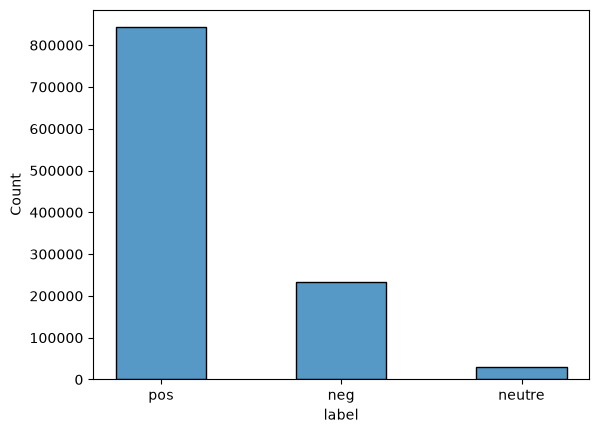

In [12]:
sns.histplot(data=df['label'], shrink=0.5)

In [13]:
import emoji

In [14]:
df['content'].apply(
    lambda x: any(char in emoji.EMOJI_DATA for char in str(x))
).sum()

np.int64(57747)

In [15]:
import re

In [16]:
def preprocess_text_without_emoji(text):
    if isinstance(text, str):
        text = re.sub(r'[\r\n]', ' ', text)
        text = re.sub(r'(\d+)([a-zA-Z]+)', r'\1 \2', text)
        doc = nlp(text.lower()) 
        tokens = [
            token.lemma_
            for token in doc
            if not token.is_punct
            and not token.is_digit
        ]
        
        return " ".join(tokens)
    else:
        return "" # Return an empty string for invalid entries

In [17]:
df['content_with_translate_emojis'] = df['content'].apply(
        lambda x: emoji.demojize(str(x), language='fr')
    )

In [18]:
df['content_with_translate_emojis']

0          Cet accompagnement m’a aidé sur une prise de c...
1          Cette expérience a permis de me découvrir au p...
2          Je recommande vivement la formation qui fait b...
3          j'étais confiante au début, puis au fur et à m...
4          Et puis un jour, l’envie d’avancer ... je déco...
                                 ...                        
1124118    Commande reçue ce jour:visage_avec_des_étoiles...
1124119    Merci pour votre temps pour l'essayage :) Shoe...
1124120    Colis arrivé dans les temps indiqué. Très cont...
1124121    Je suis professeur de danse en talons et danse...
1124122    J’ai commandé des chaussures pour un mariage f...
Name: content_with_translate_emojis, Length: 1105228, dtype: str

In [19]:
df['processed_content'] = df['content'].apply(preprocess_text_without_emoji)

In [20]:
df['processed_content_with_translate_emojis'] = df['content_with_translate_emojis'].apply(preprocess_text_without_emoji)

In [21]:
from sklearn.preprocessing import LabelEncoder


In [22]:
df['sentiments'] = df['label']

In [23]:
# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiments'])

In [24]:
df.sample(50)

,content,label,content_with_translate_emojis,processed_content,processed_content_with_translate_emojis,sentiments
318735,Plate-forme à l'arrêt ! 1 an qu'ils doivent fa...,0,Plate-forme à l'arrêt ! 1 an qu'ils doivent fa...,plate forme à le arrêt an que il devoir faire ...,plate forme à le arrêt an que il devoir faire ...,neg
1113095,"Juste incroyable, rapport qualité prix au top,...",2,"Juste incroyable, rapport qualité prix au top,...",juste incroyable rapport qualité prix au top e...,juste incroyable rapport qualité prix au top e...,pos
628996,j ai qu’un mot à dire le professionnalisme.\nl...,2,j ai qu’un mot à dire le professionnalisme.\nl...,j avoir qu’ un mot à dire le professionnalisme...,j avoir qu’ un mot à dire le professionnalisme...,pos
895334,"suite à une vidéo de Jordan de la boutique ""Bo...",2,"suite à une vidéo de Jordan de la boutique ""Bo...",suite à un vidéo de jordan de le boutique bon ...,suite à un vidéo de jordan de le boutique bon ...,pos
221900,"Excellent site mes chouchoutes sont Léa, et Ca...",2,"Excellent site mes chouchoutes sont Léa, et Ca...",excellent site mon chouchou être léa et cassan...,excellent site mon chouchou être léa et cassan...,pos
934502,Beaucoup de retard dans la livraison et je n'a...,0,Beaucoup de retard dans la livraison et je n'a...,beaucoup de retard dans le livraison et je ne ...,beaucoup de retard dans le livraison et je ne ...,neg
965922,"Expérience super, toujours rapide et top quali...",2,"Expérience super, toujours rapide et top quali...",expérience super toujours rapide et top qualit...,expérience super toujours rapide et top qualit...,pos
751143,"poignée valise non fonctionnelle,bloquée.étant...",2,"poignée valise non fonctionnelle,bloquée.étant...",poignée valise non fonctionnel bloquée.éter en...,poignée valise non fonctionnel bloquée.éter en...,pos
988569,RAS tout était impeccable,2,RAS tout était impeccable,ras tout être impeccable,ras tout être impeccable,pos
719782,Suite à la reprise de notre dossier par Pitche...,2,Suite à la reprise de notre dossier par Pitche...,suite à le reprise de notre dossier par pitche...,suite à le reprise de notre dossier par pitche...,pos


In [25]:
df['content'].apply(
    lambda x: any(char in emoji.EMOJI_DATA for char in str(x))
).sum()

np.int64(57747)

In [26]:
df.to_parquet(path='../data/preprocess_reviews.gzip', compression='gzip')